# 1. Question

## Research Question

Can observable search, content, and engagement signals be used to rank content pages that should be reviewed first for refresh or improvement?

## Decision Supported

The project supports the decision of which content pages a reviewer should inspect first when time and review capacity are limited.

## Unit of Analysis

One row represents one pseudonymized content page.

## Intended Output

The output is a ranked content-review queue containing:

* a priority score,
* a priority band,
* reason codes,
* and a suggested review action.

The system is intended for decision support. It does not automatically determine whether a page should be edited, removed, merged, or republished.


# 2. Data

This project uses the FlyRank starter dataset:

`data/raw/content_refresh_anonymized.csv`

The dataset contains **30,000 rows and 44 columns**, with one row representing one pseudonymized content page. It includes trailing 90-day search, content, and engagement signals such as impressions, clicks, sessions, CTR, average position, content age, days since last update, engagement rate, scroll rate, and AI traffic percentage.

This capstone does **not** use the full FlyRank warehouse release of approximately 79 million daily rows. Results therefore apply only to the 30,000-row starter dataset and should not be presented as a warehouse-scale benchmark.

The starter dataset is a current snapshot with trailing 90-day aggregates rather than a full time-series dataset. Because of this, the target used later is a proxy based on the current trend bucket rather than a future outcome.

The following fields were excluded from the model:

- `content_id` and `client_id` as predictive features, because they are pseudonymous identifiers rather than meaningful signals.
- `trend_direction` and `trend_pct` as features, because the target is derived from them and using them would create label leakage.
- Any client names, domains, URLs, raw queries, or private text, none of which are included in the public starter dataset.

Rate fields such as CTR, engagement rate, scroll rate, AI traffic percentage, and trend percentage are stored as percentage-point values. For example, `ctr = 0.76` means 0.76%, not 76%.

In [10]:
import pandas as pd

df = pd.read_csv("content_refresh_anonymized.csv")

print("Shape:", df.shape)
print("Unique clients:", df["client_id"].nunique())
print("Date structure: trailing 90-day aggregates, not daily time series")
print("Target distribution:")
print(df["trend_direction"].value_counts())

Shape: (30000, 44)
Unique clients: 32
Date structure: trailing 90-day aggregates, not daily time series
Target distribution:
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64


# 3. Methodology

## Problem Formulation

This project is framed as a ranking and scoring problem. The objective is to prioritize content pages for manual review based on search performance and engagement signals rather than automatically deciding whether content should be updated.

## Features

The model uses search and engagement features including:

- Search volume
- Competition
- CPC
- Word count
- Character count
- Impressions
- Clicks
- Sessions
- Content age
- Days since last update
- CTR
- Average search position
- Engagement rate
- Scroll rate
- AI traffic percentage

Pseudonymous identifiers (`content_id` and `client_id`) were excluded as predictive features.

## Target Definition

The target is a proxy label derived from `trend_direction`.

Pages labeled **down** were treated as positive examples requiring review, while all other trend categories were treated as negative examples.

## Baseline

A simple rule-based baseline was used for comparison. Machine learning models were then evaluated against this baseline using the same dataset and evaluation procedure.

## Model Selection

Three supervised learning models were evaluated:

- Logistic Regression
- Decision Tree
- Random Forest

Random Forest achieved the strongest overall balance between precision and recall and was selected for the action playbook.

## Validation

Two validation strategies were used.

1. Random train/test split (80/20)
2. Grouped validation using `client_id`

The grouped split provides a more realistic estimate of performance on unseen clients.

## Leakage Checks

To reduce label leakage:

- `trend_direction`
- `trend_pct`

were excluded from the feature set because the prediction target is derived from these variables.

Identifiers were never used as predictive features.

In [11]:
results = pd.DataFrame({
    "Validation": [
        "Random Split",
        "Grouped by Client"
    ],
    "Accuracy": [
        0.6965,
        0.5306
    ],
    "Precision": [
        0.7041,
        0.5338
    ],
    "Recall": [
        0.7589,
        0.6424
    ],
    "F1 Score": [
        0.7305,
        0.5831
    ]
})

display(results)

,Validation,Accuracy,Precision,Recall,F1 Score
0,Random Split,0.6965,0.7041,0.7589,0.7305
1,Grouped by Client,0.5306,0.5338,0.6424,0.5831


# 4. Results (vs Baseline)

Three machine learning models were evaluated using the same train/test split. Random Forest achieved the best overall performance and was selected for generating the ranked review queue.

To evaluate generalization, the model was also tested using a grouped validation split based on client ID. Performance decreased compared with the random split, indicating that the random split likely benefited from information shared across clients. The grouped split provides a more realistic estimate of performance on previously unseen clients.

These results should be interpreted as measured performance on the starter dataset and are intended to support prioritization decisions rather than prove causal relationships.

In [12]:
comparison = pd.DataFrame({
    "Validation": ["Random Split", "Grouped by Client"],
    "Accuracy": [0.6965, 0.5306],
    "Precision": [0.7041, 0.5338],
    "Recall": [0.7589, 0.6424],
    "F1 Score": [0.7305, 0.5831]
})

display(comparison)

,Validation,Accuracy,Precision,Recall,F1 Score
0,Random Split,0.6965,0.7041,0.7589,0.7305
1,Grouped by Client,0.5306,0.5338,0.6424,0.5831


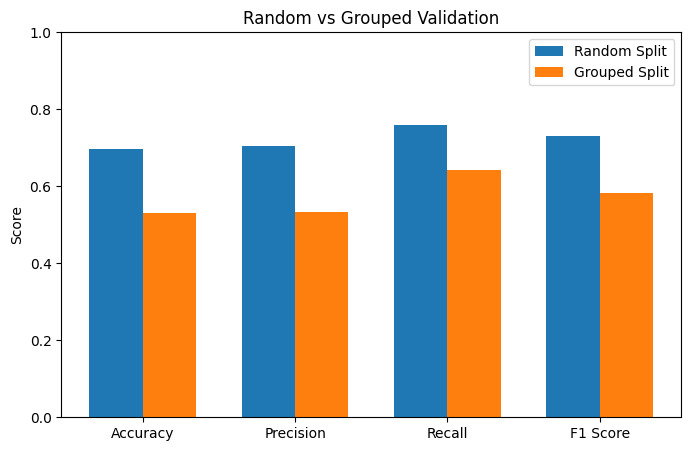

In [13]:
import matplotlib.pyplot as plt

metrics = ["Accuracy","Precision","Recall","F1 Score"]

random_scores = [0.6965,0.7041,0.7589,0.7305]
group_scores = [0.5306,0.5338,0.6424,0.5831]

x = range(len(metrics))
w = 0.35

plt.figure(figsize=(8,5))
plt.bar([i-w/2 for i in x], random_scores, width=w, label="Random Split")
plt.bar([i+w/2 for i in x], group_scores, width=w, label="Grouped Split")

plt.xticks(x, metrics)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Random vs Grouped Validation")
plt.legend()

plt.savefig("work/outputs/model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# 5. Limitations

This work uses the 30,000-row FlyRank starter dataset rather than the complete warehouse release. The target variable is a proxy derived from the observed trend category and should not be interpreted as future content performance.

The model identifies patterns associated with declining content but does not establish causal relationships. Recommendations should always be reviewed by a human before making publishing decisions. The evaluation is based on the available snapshot data and may not generalize to different datasets, industries, or future search environments.

# 6. Ranked Recommendations

The final output of this project is a ranked content review queue.

Priority recommendations include:

| Priority | Recommended Action |
|-----------|-------------------|
| High | Review titles, metadata, search intent, and outdated content immediately. |
| Medium | Improve readability, content quality, and user engagement. |
| Low | Continue monitoring and periodically reassess performance. |

The model generates supporting reason codes to explain each recommendation. These recommendations are intended to assist human reviewers and should not be executed automatically.

# 7. Artifacts the Paper Embeds

The deployed research paper includes the following artifacts:

- Model comparison table
- Random vs grouped validation chart
- Feature importance chart
- Ranked action queue
- Priority distribution
- Methodology summary
- Validation summary

In [14]:
import os

os.makedirs("work/outputs", exist_ok=True)

comparison.to_csv(
    "work/outputs/model_results.csv",
    index=False
)

print("Artifacts exported successfully.")

Artifacts exported successfully.


# Self-check

- Completed every required paper section.
- Used only the public 30,000-row starter dataset.
- Included methodology, validation, leakage checks, and limitations.
- Compared model performance using random and grouped validation.
- Generated a ranked action playbook with explainable reason codes.
- Exported reusable artifacts for the deployed research paper.
- Used careful, evidence-based language throughout.